# Домашнее задание №1

Темы "Введение в МатСтат" и "Виды статистических оценок и характеристики"

Общие положения:
- Макс кол-во баллов за ДЗ - 25 баллов

Список заданий:
1. Посчитайте кол-во уникальных жанров.  
2. Посчитайте и визуализируйте средний рейтинг и стандартное отклонение по типу аниме `type`.  
3. Посчитайте и визуализируйте средний рейтинг и стандартное отклонение по жанрам `genre`.  
4. Посчитайте и визуализируйте квартили Q1, Q2 и Q3 с интерквантильным размахом по жанрам `genre` и типу аниме `type`.  
5. Насколько часто встречаются аниме с одним или двумя жанрами?  
6. Сколько в среднем эпизодов приходится на аниме типа == `TV`?  
7. По правилу трех сигм на столбцах `episodes`, `rating` и `members` оцените кол-во аномалий.  
  - если по одному из столбцов аниме не попадает в интервал трех сигм, то оно считается аномальным
8. Оцените и визуализируйте корреляцию среднего рейтинга жанра со средними кол-вом эпизодов и кол-вом подписчиков.  
9. Оцените и визуализируйте корреляцию кол-ва жанров у аниме с его рейтингом и кол-вом подписчиков по каждому типу аниме `type`.  
10. Оцените и визуализируйте корреляцию длины названия аниме `name` с его рейтингом, кол-вом жанров, эпизодов и подписчиков.  



In [612]:
import numpy as np
import pandas as pd

# Не обязательно, можно использовать любую удобную вам библиотеку для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [613]:
!curl -O https://raw.githubusercontent.com/practical-jupyter/sample-data/refs/heads/master/anime/anime.csv >> anime.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file anime.csv: Permission denied

  0  778k    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 16384 bytes


Описание датафрейма:
- `anime_id` - ID
- `name` - название
- `genre` - жанр (строка с пречисление через запятую)
- `type` - формат
- `episodes` - кол-во эпизодов
- `rating` - средний рейтинг
- `members` - кол-во смотрящих

In [614]:
df = pd.read_csv('./anime.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  10486 non-null  int64  
 1   name      10486 non-null  object 
 2   genre     10424 non-null  object 
 3   type      10463 non-null  object 
 4   episodes  10486 non-null  object 
 5   rating    10275 non-null  float64
 6   members   10486 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 573.6+ KB


In [615]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


## 1. Посчитайте кол-во уникальных жанров.  

In [616]:
all_genres = df['genre'].dropna().str.split(', ').explode().str.strip()
all_genres.nunique()

39

## 2. Посчитайте и визуализируйте средний рейтинг и стандартное отклонение по типу аниме type.  

In [617]:
df.groupby('type')['rating'].agg(['mean', 'std'])

,mean,std
type,,
Movie,6.311996,1.213470
Music,5.584259,0.956994
ONA,5.633297,1.131859
OVA,6.474058,0.925699
Special,6.523434,0.913829
TV,6.900149,0.879673


## 3. Посчитайте и визуализируйте средний рейтинг и стандартное отклонение по жанрам.  
График постройте для топ-15 жанров по рейтингу

In [618]:
df_genres = df.dropna(subset=['genre']).copy()
df_genres = df_genres.assign(genre=df_genres['genre'].str.split(', '))

df_genres = df_genres.explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()

genre_stats = df_genres.groupby('genre')['rating'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

top15 = genre_stats.head(15)
top15

,mean,std,count
genre,,,
Josei,7.443077,0.774745,52
Thriller,7.382326,1.087528,86
Mystery,7.254219,0.832180,474
Shoujo Ai,7.197073,0.516751,41
Police,7.159076,0.810693,184
Romance,7.064291,0.793598,1156
Shounen,7.060198,0.837901,1563
Psychological,7.049171,1.129191,217
Supernatural,7.037846,0.949181,859


In [619]:
import plotly.express as px

fig = px.bar(
    top15.reset_index(),
    x='genre',
    y='mean',
    error_y='std',
    title='Топ-15 жанров по среднему рейтингу',
    labels={'mean':'Средний рейтинг', 'genre':'Жанр'}
)
fig.show()

## 4. Посчитайте и визуализируйте квартили Q1, Q2 и Q3 с интерквантильным размахом по жанрам genre и типу аниме type.  

In [620]:
genre_quartiles = df_genres.groupby('genre')['rating'].quantile([0.25, 0.5, 0.75]).unstack()
genre_quartiles.columns = ['Q1', 'Q2', 'Q3']
genre_quartiles['IQR'] = genre_quartiles['Q3'] - genre_quartiles['Q1']
genre_quartiles.head()

,Q1,Q2,Q3,IQR
genre,,,,
Action,6.300,6.910,7.440,1.140
Adventure,6.310,6.790,7.320,1.010
Cars,5.570,6.595,7.495,1.925
Comedy,6.060,6.740,7.340,1.280
Dementia,4.215,4.870,5.500,1.285


In [621]:
type_quartiles = df.groupby('type')['rating'].quantile([0.25, 0.5, 0.75]).unstack()
type_quartiles.columns = ['Q1', 'Q2', 'Q3']
type_quartiles['IQR'] = type_quartiles['Q3'] - type_quartiles['Q1']
type_quartiles

,Q1,Q2,Q3,IQR
type,,,,
Movie,5.40,6.450,7.25,1.85
Music,5.01,5.615,6.15,1.14
ONA,4.86,5.750,6.41,1.55
OVA,5.89,6.460,7.11,1.22
Special,6.05,6.630,7.14,1.09
TV,6.43,6.940,7.47,1.04


<Figure size 1200x600 with 0 Axes>

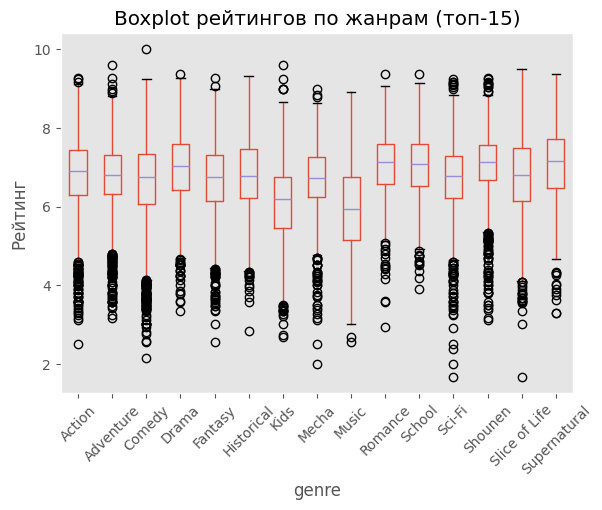

In [622]:
import matplotlib.pyplot as plt

top_genres = df_genres['genre'].value_counts().head(15).index
df_top_genres = df_genres[df_genres['genre'].isin(top_genres)]

plt.figure(figsize=(12,6))
df_top_genres.boxplot(column='rating', by='genre', grid=False, rot=45)
plt.title("Boxplot рейтингов по жанрам (топ-15)")
plt.suptitle("")
plt.ylabel("Рейтинг")
plt.show()

<Figure size 800x500 with 0 Axes>

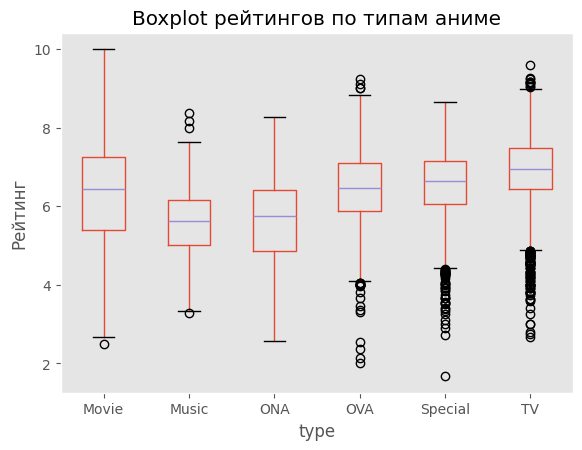

In [623]:
plt.figure(figsize=(8,5))
df.boxplot(column='rating', by='type', grid=False)
plt.title("Boxplot рейтингов по типам аниме")
plt.suptitle("")
plt.ylabel("Рейтинг")
plt.show()

## 5. Насколько часто встречаются аниме с одним или двумя жанрами?  

In [624]:
df['n_genres'] = df['genre'].dropna().apply(lambda x: len(x.split(', ')))

counts = df['n_genres'].value_counts().sort_index()

print("Аниме с 1 жанром:", counts.get(1, 0))
print("Аниме с 2 жанрами:", counts.get(2, 0))

total = len(df['genre'].dropna())
one_two_share = counts.loc[[2]].sum() / total * 100
print(f"Аниме с 2 жанрами: {one_two_share:.2f}% от всех")


Аниме с 1 жанром: 1957
Аниме с 2 жанрами: 2479
Аниме с 2 жанрами: 23.78% от всех


## 6. Сколько в среднем эпизодов приходится на аниме типа == TV?  

In [625]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
mean_eps_tv = df.loc[df['type'] == 'TV', 'episodes'].mean()
print(f"Среднее количество эпизодов для TV-аниме: {mean_eps_tv:.2f}")

Среднее количество эпизодов для TV-аниме: 37.38


## 7. По правилу трех сигм на столбцах episodes, rating и members оцените кол-во аномалий.  
если по одному из столбцов аниме не попадает в интервал трех сигм, то оно считается аномальным


In [626]:
cols = ['episodes', 'rating', 'members']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

anomalies = pd.Series(False, index=df.index)
anom_counts = {}

for col in cols:
    mu, sigma = df[col].mean(), df[col].std()
    lower, upper = mu - 3*sigma, mu + 3*sigma
    col_anom = (df[col] < lower) | (df[col] > upper)
    anom_counts[col] = col_anom.sum()
    anomalies |= col_anom

print("Количество аномалий всего:", anomalies.sum())
for col, count in anom_counts.items():
    print(f"Аномалий по {col}: {count}")


Количество аномалий всего: 314
Аномалий по episodes: 63
Аномалий по rating: 41
Аномалий по members: 218


## 8. Оцените и визуализируйте корреляцию среднего рейтинга жанра со средними кол-вом эпизодов и кол-вом подписчиков.  

episodes    0.166220
members     0.588216
Name: rating, dtype: float64


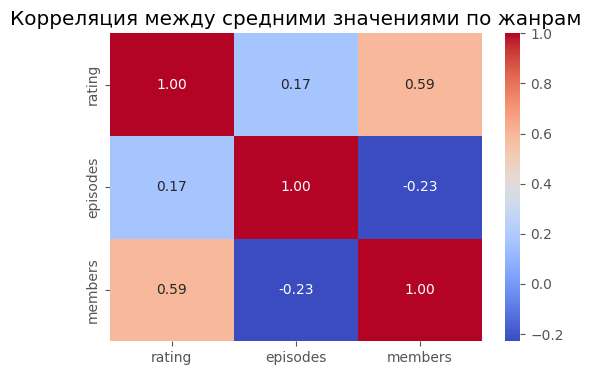

In [627]:
df_genres = df.dropna(subset=['genre']).copy()
df_genres = df_genres.assign(genre=df_genres['genre'].str.split(', '))

df_genres = df_genres.explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()

df_genres_grouped = df_genres.groupby('genre').agg({
    'rating': 'mean',
    'episodes': 'mean',
    'members': 'mean'
})

corr = df_genres_grouped.corr()
print(corr['rating'][['episodes', 'members']])

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция между средними значениями по жанрам")
plt.show()


## 9. Оцените и визуализируйте корреляцию кол-ва жанров у аниме с его рейтингом и кол-вом подписчиков по каждому типу аниме type.  

           rating   members
Movie    0.456328  0.278339
Music    0.048063  0.074358
ONA      0.341561  0.160593
OVA      0.300684  0.229513
Special  0.354200  0.203654
TV       0.411874  0.288896


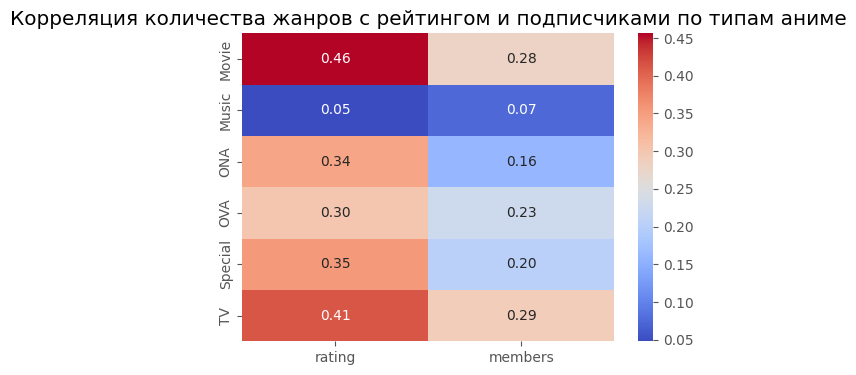

In [628]:
df['n_genres'] = df['genre'].dropna().apply(lambda x: len(x.split(', ')))

corrs = {}
for t, subdf in df.groupby('type'):
    corrs[t] = subdf[['n_genres', 'rating', 'members']].corr().loc['n_genres', ['rating', 'members']]

corrs_df = pd.DataFrame(corrs).T
print(corrs_df)

plt.figure(figsize=(6,4))
sns.heatmap(corrs_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция количества жанров с рейтингом и подписчиками по типам аниме")
plt.show()

## 10. Оцените и визуализируйте корреляцию длины названия аниме name с его рейтингом, кол-вом жанров, эпизодов и подписчиков.  

rating      0.120270
n_genres    0.081084
episodes   -0.091011
members    -0.077829
Name: name_length, dtype: float64


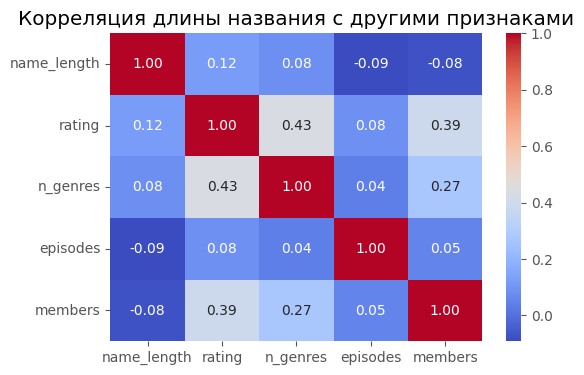

In [629]:
df = df.dropna()
df['name_length'] = df['name'].str.len()

corr = df[['name_length', 'rating', 'n_genres', 'episodes', 'members']].corr()
print(corr['name_length'][['rating','n_genres','episodes','members']])

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция длины названия с другими признаками")
plt.show()

# 2. Часть

Каждое задание оценивается 1 баллом в случае полного выполнения

Обязательно фиксируем seed(42) и генерируем все выборки через numpy

In [630]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)

from scipy import stats

 ### Задание 11: Нормальное распределение  
Генерация данных \
Сгенерируйте выборку из 1000 элементов с нормальным распределением, где среднее  μ=5 и стандартное отклонение σ=1.5.
Описательная статистика \
Рассчитайте выборочное среднее, выборочную медиану, выборочную моду и стандартное отклонение. \
Графическое представление \
Постройте гистограмму и график плотности распределения. Сравните выборочные статистики с теоретическими. \
Анализ отклонений \
Рассчитайте частоту значений, которые отклоняются от среднего на более чем одно стандартное отклонение, и сравните это с теоретическим результатом для нормального распределения.

Выборочное среднее: 5.029
Выборочная медиана: 5.038
Выборочная мода: 0.138
Выборочное стандартное отклонение: 1.469


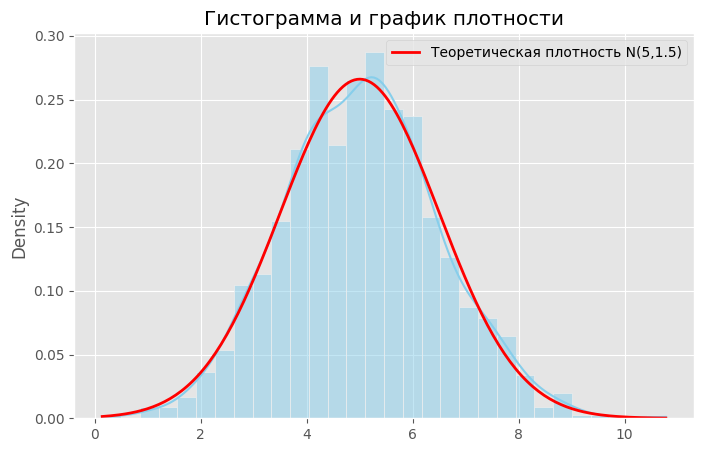

Эмпирическая доля отклонений > 1σ: 0.314
Теоретическая доля отклонений > 1σ: 0.317
Доля значений в пределах одного σ: 0.686


In [631]:
random.seed(42)
np.random.seed(42)
data = np.random.normal(loc=5, scale=1.5, size=1000)

mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data, keepdims=True)[0][0]
std = np.std(data, ddof=1)

print(f"Выборочное среднее: {mean:.3f}")
print(f"Выборочная медиана: {median:.3f}")
print(f"Выборочная мода: {mode:.3f}")
print(f"Выборочное стандартное отклонение: {std:.3f}")

plt.figure(figsize=(8,5))
sns.histplot(data, bins=30, kde=True, stat="density", color="skyblue")
x = np.linspace(min(data), max(data), 200)
plt.plot(x, stats.norm.pdf(x, 5, 1.5), 'r', lw=2, label="Теоретическая плотность N(5,1.5)")
plt.legend()
plt.title("Гистограмма и график плотности")
plt.show()

empirical_freq = np.mean(np.abs(data - mean) > std)
theoretical_freq = 1 - stats.norm.cdf(1) + stats.norm.cdf(-1)
print(f"Эмпирическая доля отклонений > 1σ: {empirical_freq:.3f}")
print(f"Теоретическая доля отклонений > 1σ: {theoretical_freq:.3f}")
empirical_share = np.mean((data > mean - std) & (data < mean + std))

print(f"Доля значений в пределах одного σ: {empirical_share:.3f}")

### Задание 12: Экспоненциальное распределение  
Генерация данных \
Сгенерируйте выборку из 1000 элементов из экспоненциального распределения с параметром λ=0.5. \
Описательная статистика \
Рассчитайте выборочное среднее, медиану и стандартное отклонение. \
Графическое представление \
Постройте гистограмму и график плотности распределения. \
Анализ распределения \
Определите долю значений в выборке, которые больше двух выборочных средних, и сравните это с теоретической вероятностью для экспоненциального распределения. \

Выборочное среднее: 1.945
Выборочная медиана: 1.374
Выборочное стандартное отклонение: 1.945


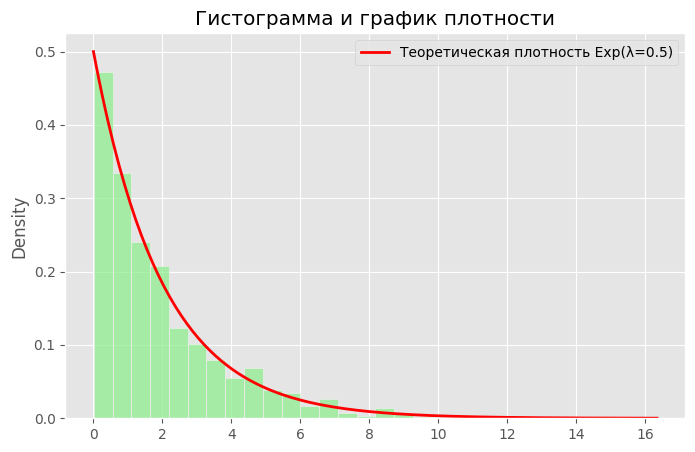

Эмпирическая вероятность X > 2*mean: 0.147
Теоретическая вероятность X > 2*mean: 0.143


In [632]:
lam = 0.5
random.seed(42)
np.random.seed(42)
data = np.random.exponential(scale=1/lam, size=1000)

mean = np.mean(data)
median = np.median(data)
std = np.std(data, ddof=1)

print(f"Выборочное среднее: {mean:.3f}")
print(f"Выборочная медиана: {median:.3f}")
print(f"Выборочное стандартное отклонение: {std:.3f}")

plt.figure(figsize=(8,5))
sns.histplot(data, bins=30, kde=False, stat="density", color="lightgreen")
x = np.linspace(0, np.max(data), 200)
plt.plot(x, stats.expon.pdf(x, scale=1/lam), 'r', lw=2, label="Теоретическая плотность Exp(λ=0.5)")
plt.legend()
plt.title("Гистограмма и график плотности")
plt.show()

empirical_prob = np.mean(data > 2*mean)
theoretical_prob = np.exp(-lam * 2 * mean)
print(f"Эмпирическая вероятность X > 2*mean: {empirical_prob:.3f}")
print(f"Теоретическая вероятность X > 2*mean: {theoretical_prob:.3f}")


### Задание 13: Биномиальное распределение  
Генерация данных \
Сгенерируйте выборку из 1000 наблюдений из биномиального распределения с параметрами  n=10 и p=0.7 \
Описательная статистика \
Найдите выборочное среднее, дисперсию и моду количества успехов. \
Графическое представление \
Постройте столбчатую диаграмму распределения количества успехов. \
Анализ вероятностей \
Вычислите вероятность того, что количество успехов будет больше 8, используя как выборочные данные, так и теоретическую вероятность биномиального распределения. Сравните результаты. \

Выборочное среднее: 7.065
Выборочная дисперсия: 2.103
Выборочная мода: 7


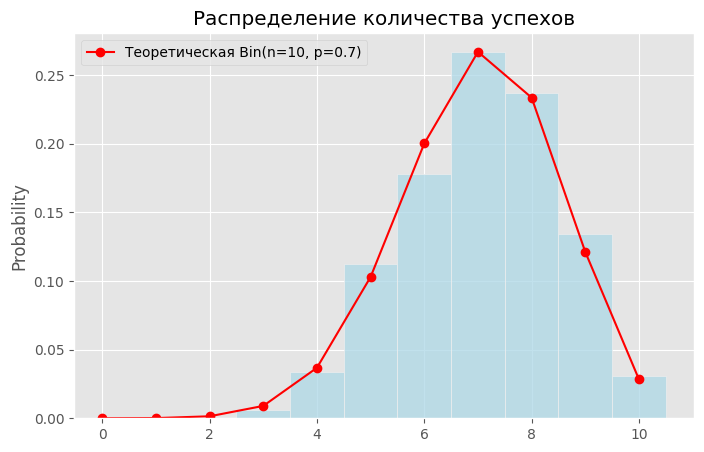

Эмпирическая вероятность X>8: 0.165
Теоретическая вероятность X>8: 0.149


In [633]:
n, p = 10, 0.7
random.seed(42)
np.random.seed(42)
data = np.random.binomial(n, p, 1000)

mean = np.mean(data)
var = np.var(data, ddof=1)
mode = stats.mode(data, keepdims=True)[0][0]

print(f"Выборочное среднее: {mean:.3f}")
print(f"Выборочная дисперсия: {var:.3f}")
print(f"Выборочная мода: {mode}")

plt.figure(figsize=(8,5))
sns.histplot(data, bins=range(n+2), discrete=True, stat="probability", color="lightblue")
x = np.arange(0, n+1)
plt.plot(x, stats.binom.pmf(x, n, p), 'ro-', label="Теоретическая Bin(n=10, p=0.7)")
plt.legend()
plt.title("Распределение количества успехов")
plt.show()

empirical_prob = np.mean(data > 8)
theoretical_prob = 1 - stats.binom.cdf(8, n, p)

print(f"Эмпирическая вероятность X>8: {empirical_prob:.3f}")
print(f"Теоретическая вероятность X>8: {theoretical_prob:.3f}")

### Задание 14: Геометрическое распределение  
Генерация данных \
Сгенерируйте выборку из 1000 наблюдений из геометрического распределения с вероятностью успеха p=0.3. \
Описательная статистика \
Рассчитайте выборочное среднее, медиану и моду количества попыток до первого успеха. \
Графическое представление \
Постройте гистограмму распределения количества попыток. \
Анализ вероятностей \
Определите вероятность того, что потребуется не более 5 попыток для первого успеха, используя как выборочные данные, так и теоретическое геометрическое распределение. Сравните результаты. \

Выборочное среднее: 3.260
Выборочная медиана: 2.000
Выборочная мода: 1


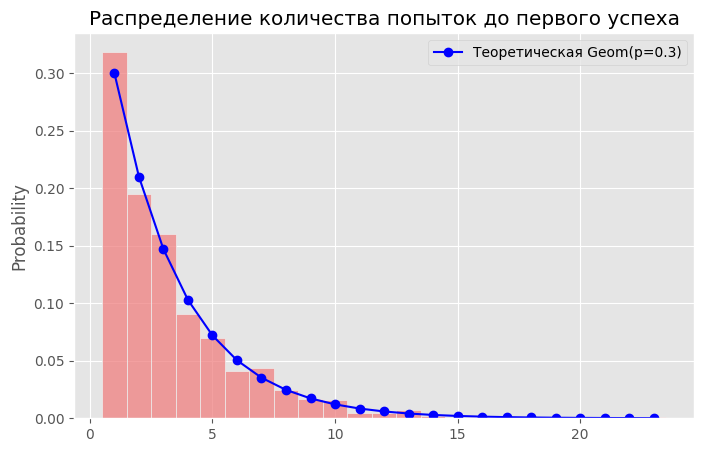

Эмпирическая вероятность X ≤ 5: 0.835
Теоретическая вероятность X ≤ 5: 0.832


In [634]:
p = 0.3
random.seed(42)
np.random.seed(42)
data = np.random.geometric(p, 1000)

mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data, keepdims=True)[0][0]

print(f"Выборочное среднее: {mean:.3f}")
print(f"Выборочная медиана: {median:.3f}")
print(f"Выборочная мода: {mode}")

plt.figure(figsize=(8,5))
sns.histplot(data, bins=range(1, max(data)+2), discrete=True, stat="probability", color="lightcoral")
x = np.arange(1, max(data)+1)
plt.plot(x, stats.geom.pmf(x, p), 'bo-', label="Теоретическая Geom(p=0.3)")
plt.legend()
plt.title("Распределение количества попыток до первого успеха")
plt.show()

empirical_prob = np.mean(data <= 5)
theoretical_prob = stats.geom.cdf(5, p)

print(f"Эмпирическая вероятность X ≤ 5: {empirical_prob:.3f}")
print(f"Теоретическая вероятность X ≤ 5: {theoretical_prob:.3f}")

### Задание 15: Равномерное распределение  
Генерация данных \
Сгенерируйте выборку из 1000 наблюдений из равномерного распределения на отрезке от 3 до 7. \
Описательная статистика \
Рассчитайте выборочное среднее, медиану и стандартное отклонение. \
Графическое представление  \
Постройте гистограмму и график плотности распределения. Сравните выборочные статистики с теоретическими значениями для равномерного распределения.
Анализ крайних значений \
Определите долю значений, которые находятся ближе к границам распределения (например, больше 6 или меньше 4), и сравните с ожидаемым результатом для равномерного распределения. \

Выборочное среднее: 4.961
Выборочная медиана: 4.987
Выборочное стандартное отклонение: 1.169


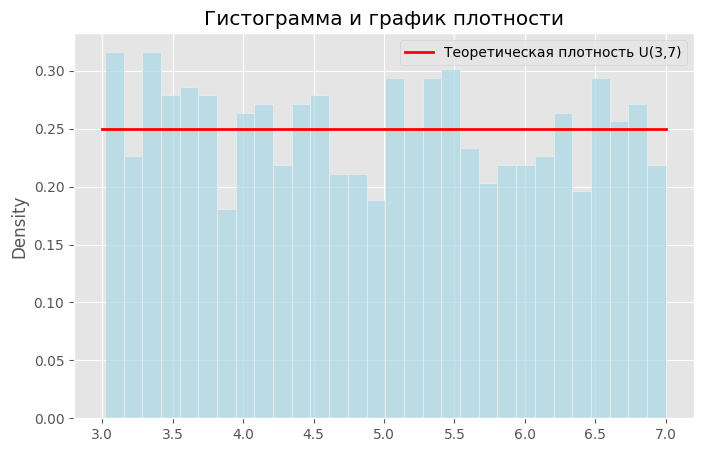

Эмпирическая вероятность X<4 или X>6: 0.512
Теоретическая вероятность X<4 или X>6: 0.500


In [635]:
a, b = 3, 7
random.seed(42)
np.random.seed(42)
data = np.random.uniform(a, b, 1000)

mean = np.mean(data)
median = np.median(data)
std = np.std(data, ddof=1)

print(f"Выборочное среднее: {mean:.3f}")
print(f"Выборочная медиана: {median:.3f}")
print(f"Выборочное стандартное отклонение: {std:.3f}")

plt.figure(figsize=(8,5))
sns.histplot(data, bins=30, stat="density", color="lightblue")
x = np.linspace(a, b, 200)
plt.plot(x, stats.uniform.pdf(x, loc=a, scale=b-a), 'r', lw=2, label="Теоретическая плотность U(3,7)")
plt.legend()
plt.title("Гистограмма и график плотности")
plt.show()

empirical_prob = np.mean((data < 4) | (data > 6))
theoretical_prob = (4-a)/(b-a) + (b-6)/(b-a)

print(f"Эмпирическая вероятность X<4 или X>6: {empirical_prob:.3f}")
print(f"Теоретическая вероятность X<4 или X>6: {theoretical_prob:.3f}")

### Задание 16: Распределение Пуассона  
Генерация данных \
Сгенерируйте выборку из 1000 наблюдений из распределения Пуассона с параметром  λ=4. \
Описательная статистика \
Найдите выборочное среднее, дисперсию и моду количества событий. \
Графическое представление \
Постройте столбчатую диаграмму распределения количества событий. \
Анализ вероятностей \
Определите вероятность того, что количество событий будет меньше 3, используя как выборочные данные, так и теоретическое распределение Пуассона. Сравните результаты. \

Выборочное среднее: 3.923
Выборочная дисперсия: 3.959
Выборочная мода: 3


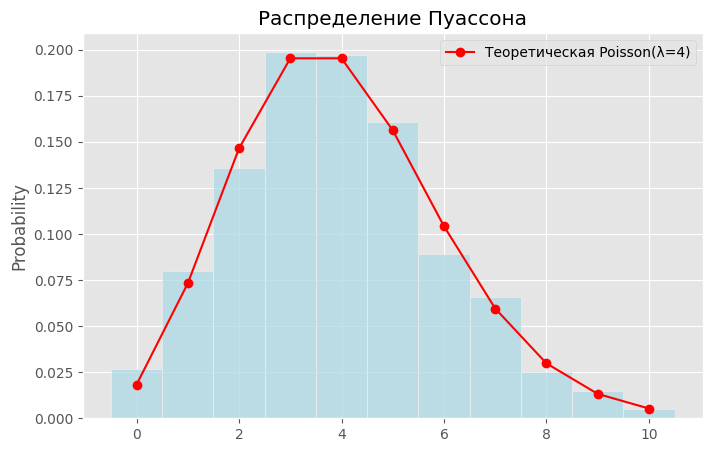

Эмпирическая вероятность X < 3: 0.243
Теоретическая вероятность X < 3: 0.238


In [636]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

random.seed(42)
np.random.seed(42)

lam = 4
data = np.random.poisson(lam, 1000)

mean = np.mean(data)
var = np.var(data, ddof=1)
mode = pd.Series(data).mode()[0]

print(f"Выборочное среднее: {mean:.3f}")
print(f"Выборочная дисперсия: {var:.3f}")
print(f"Выборочная мода: {mode}")

plt.figure(figsize=(8,5))
sns.histplot(data, bins=range(0, max(data)+2), discrete=True, stat="probability", color="lightblue")
x = np.arange(0, max(data)+1)
plt.plot(x, stats.poisson.pmf(x, lam), 'ro-', label="Теоретическая Poisson(λ=4)")
plt.legend()
plt.title("Распределение Пуассона")
plt.show()

empirical_prob = np.mean(data < 3)
theoretical_prob = stats.poisson.cdf(2, lam)

print(f"Эмпирическая вероятность X < 3: {empirical_prob:.3f}")
print(f"Теоретическая вероятность X < 3: {theoretical_prob:.3f}")

# 3 Часть

## Задание 17: Проверка несмещённости и состоятельности выборочного среднего рейтингов
1. Вычисление генерального среднего рейтингов \
Рассчитайте выборочное среднее рейтингов всех аниме. \
2. Проверка несмещённости оценки выборочного среднего \
Сгенерируйте 1000 выборок объёма n=100 с возвращением из исходных данных.
Для каждой выборки вычислите выборочное среднее рейтингов.
Постройте гистограмму распределения полученных выборочных средних.
Вычислите среднее из выборочных средних и сравните его с генеральным средним исходных данных. Сделайте вывод о несмещенности оценки.  
3. Проверка состоятельности оценки выборочного среднего. \
Повторите шаги из пункта 2 для различных объёмов выборки: n=50, 200, 500.
Для каждого объёма выборки вычислите дисперсию выборочных средних.
Постройте график зависимости дисперсии выборочных средних от объёма выборки.
Проанализируйте, как дисперсия уменьшается с увеличением объёма выборки. Сделайте вывод о состоятельности оценки.  

Генеральное среднее рейтингов: 6.508


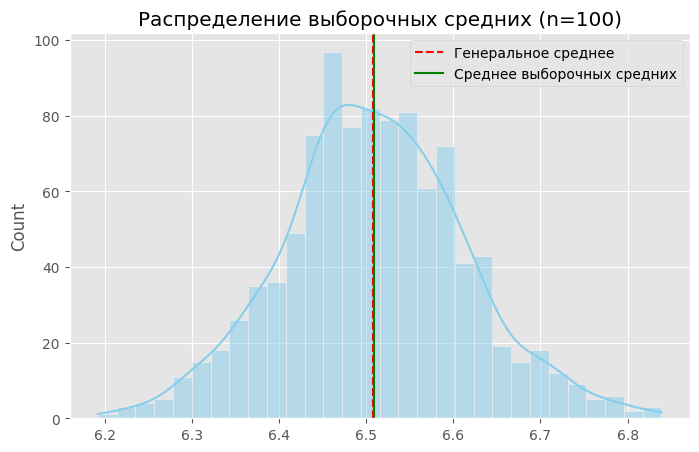

Среднее выборочных средних: 6.509


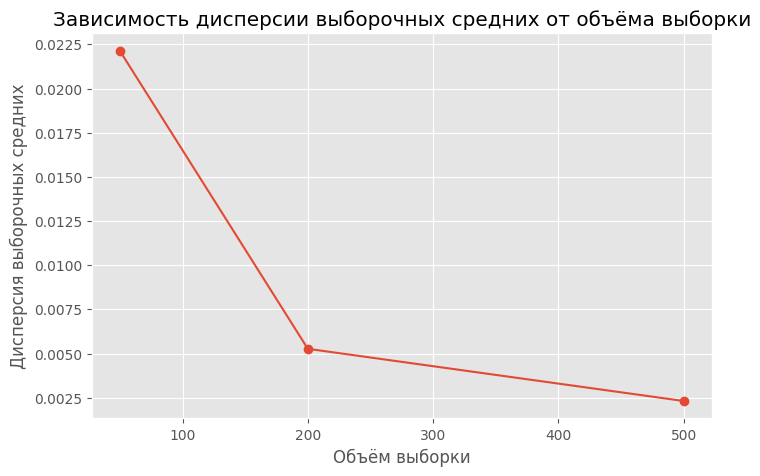

n=50, дисперсия выборочных средних: 0.02213
n=200, дисперсия выборочных средних: 0.00527
n=500, дисперсия выборочных средних: 0.00232


In [637]:
population_mean = df['rating'].mean()
print(f"Генеральное среднее рейтингов: {population_mean:.3f}")

sample_means = [df['rating'].sample(n=100, replace=True).mean() for _ in range(1000)]
mean_of_means = np.mean(sample_means)

plt.figure(figsize=(8,5))
sns.histplot(sample_means, bins=30, kde=True, color="skyblue")
plt.axvline(population_mean, color='r', linestyle='--', label="Генеральное среднее")
plt.axvline(mean_of_means, color='g', linestyle='-', label="Среднее выборочных средних")
plt.legend()
plt.title("Распределение выборочных средних (n=100)")
plt.show()

print(f"Среднее выборочных средних: {mean_of_means:.3f}")

sample_sizes = [50, 200, 500]
variances = []

for n in sample_sizes:
    sample_means = [df['rating'].sample(n=n, replace=True).mean() for _ in range(1000)]
    var = np.var(sample_means, ddof=1)
    variances.append(var)

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, variances, marker='o')
plt.title("Зависимость дисперсии выборочных средних от объёма выборки")
plt.xlabel("Объём выборки")
plt.ylabel("Дисперсия выборочных средних")
plt.show()

for n, var in zip(sample_sizes, variances):
    print(f"n={n}, дисперсия выборочных средних: {var:.5f}")

## Задание 18: Проверка несмещённости и состоятельности медианы рейтингов
1. Вычисление генеральной медианы \
Рассчитайте медиану рейтингов по всему датасету.
2. Проверка несмещённости медианы \
Сгенерируйте 1000 выборок объёма n=100 с возвращением.
Для каждой выборки вычислите медиану рейтингов.
Постройте гистограмму распределения полученных медиан.
Вычислите среднее из медиан и сравните с медианой исходных данных. Сделайте вывод о несмещенности оценки.  
3. Проверка состоятельности медианы \
Повторите шаги из пункта 2 для n=50, 200, 500.
Для каждого объёма выборки вычислите стандартное отклонение медиан.
Постройте график зависимости стандартного отклонения медиан от объёма выборки.
Проанализируйте изменение разброса медиан с ростом объёма выборки. Сделайте вывод о состоятельности оценки.  

Генеральная медиана рейтингов: 6.610


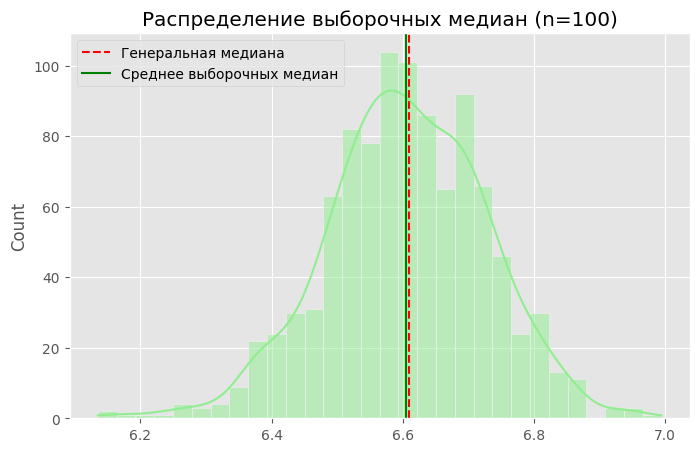

Среднее выборочных медиан: 6.605


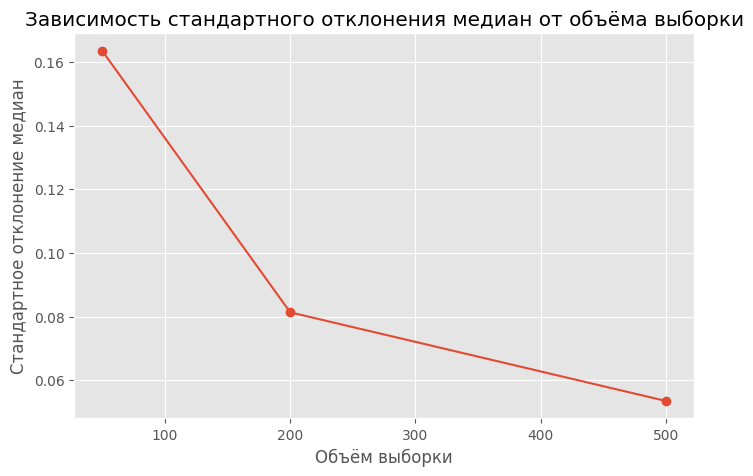

n=50, стандартное отклонение медиан: 0.16348
n=200, стандартное отклонение медиан: 0.08139
n=500, стандартное отклонение медиан: 0.05354


In [638]:
population_median = df['rating'].median()
print(f"Генеральная медиана рейтингов: {population_median:.3f}")

sample_medians = [df['rating'].sample(n=100, replace=True).median() for _ in range(1000)]
mean_of_medians = np.mean(sample_medians)

plt.figure(figsize=(8,5))
sns.histplot(sample_medians, bins=30, kde=True, color="lightgreen")
plt.axvline(population_median, color='r', linestyle='--', label="Генеральная медиана")
plt.axvline(mean_of_medians, color='g', linestyle='-', label="Среднее выборочных медиан")
plt.legend()
plt.title("Распределение выборочных медиан (n=100)")
plt.show()

print(f"Среднее выборочных медиан: {mean_of_medians:.3f}")

sample_sizes = [50, 200, 500]
stds = []

for n in sample_sizes:
    sample_medians = [df['rating'].sample(n=n, replace=True).median() for _ in range(1000)]
    std = np.std(sample_medians, ddof=1)
    stds.append(std)

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, stds, marker='o')
plt.title("Зависимость стандартного отклонения медиан от объёма выборки")
plt.xlabel("Объём выборки")
plt.ylabel("Стандартное отклонение медиан")
plt.show()

for n, std in zip(sample_sizes, stds):
    print(f"n={n}, стандартное отклонение медиан: {std:.5f}")

## Задание 19: Проверка несмещённости и состоятельности выборочной дисперсии рейтингов
1. Вычисление выборочной дисперсии \
Рассчитайте выборочную дисперсию рейтингов по всему датасету.
2. Проверка несмещённости оценки выборочной дисперсии \
Сгенерируйте 1000 выборок объёма n=100 с возвращением.
Для каждой выборки вычислите выборочную дисперсию.
Постройте гистограмму распределения полученных дисперсий.
Вычислите среднее из дисперсий и сравните с выборочной дисперсией исходных данных. Сделайте вывод о несмещенности оценки.  
3. Проверка состоятельности оценки выборочной дисперсии \
Повторите шаги из пункта 2 для n=50, 200, 500.
Для каждого объёма выборки вычислите дисперсию оценок выборочной дисперсии.
Постройте график зависимости дисперсии оценок выборочной дисперсии от объёма выборки.
Проанализируйте изменение разброса оценок с ростом объёма выборки.  Сделайте вывод о состоятельности оценки.  

Выборочная дисперсия рейтингов: 1.118


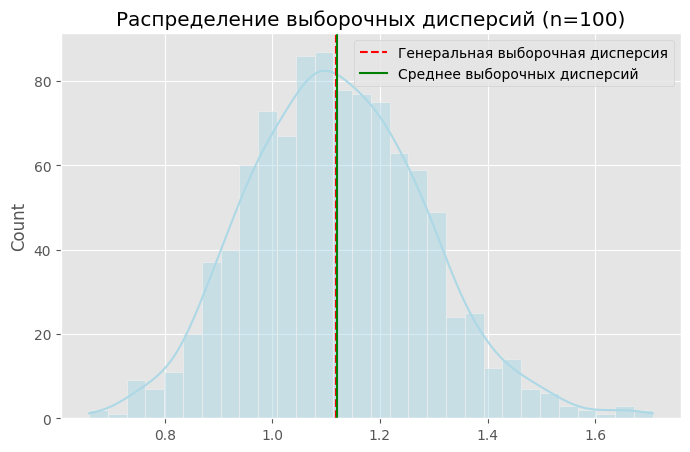

Среднее выборочных дисперсий: 1.121


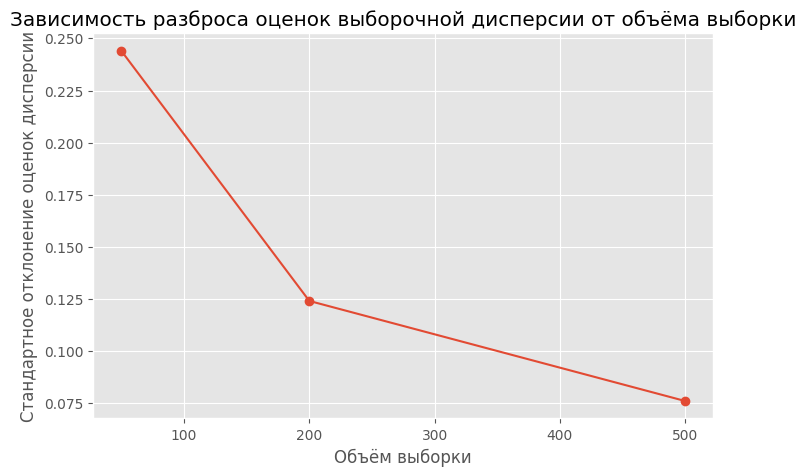

n=50, стандартное отклонение оценок дисперсии: 0.24400
n=200, стандартное отклонение оценок дисперсии: 0.12413
n=500, стандартное отклонение оценок дисперсии: 0.07615


In [639]:
population_var = df['rating'].var(ddof=1)
print(f"Выборочная дисперсия рейтингов: {population_var:.3f}")

sample_vars = [df['rating'].sample(n=100, replace=True).var(ddof=1) for _ in range(1000)]
mean_of_vars = np.mean(sample_vars)

plt.figure(figsize=(8,5))
sns.histplot(sample_vars, bins=30, kde=True, color="lightblue")
plt.axvline(population_var, color='r', linestyle='--', label="Генеральная выборочная дисперсия")
plt.axvline(mean_of_vars, color='g', linestyle='-', label="Среднее выборочных дисперсий")
plt.legend()
plt.title("Распределение выборочных дисперсий (n=100)")
plt.show()

print(f"Среднее выборочных дисперсий: {mean_of_vars:.3f}")

sample_sizes = [50, 200, 500]
stds = []

for n in sample_sizes:
    sample_vars = [df['rating'].sample(n=n, replace=True).var(ddof=1) for _ in range(1000)]
    std = np.std(sample_vars)
    stds.append(std)

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, stds, marker='o')
plt.title("Зависимость разброса оценок выборочной дисперсии от объёма выборки")
plt.xlabel("Объём выборки")
plt.ylabel("Стандартное отклонение оценок дисперсии")
plt.show()

for n, std in zip(sample_sizes, stds):
    print(f"n={n}, стандартное отклонение оценок дисперсии: {std:.5f}")